In [3]:
from google.colab import files
uploaded = files.upload()

Saving flipkart_sales_data to flipkart_sales_data (1)


In [12]:
import pandas as pd

df = pd.read_excel('flipkart_sales_data')
df.head()

,Order ID,Product Category,Sales Amount,Quantity Sold,Order Date,Region,Customer Rating,Payment Method,Discount (%)
0,ORD_1,Home Decor,16295.0,2.0,2023-01-01 00:00:00,East,1.5,UPI,10.0
1,ORD_2,Beauty & Health,1360.0,5.0,2023-01-01 12:00:00,West,3.1,Credit Card,15.0
2,ORD_3,Electronics,5890.0,1.0,2023-01-02 00:00:00,Central,1.5,Net Banking,5.0
3,ORD_4,Home Decor,12464.0,7.0,2023-01-02 12:00:00,South,2.1,UPI,5.0
4,ORD_5,Grocery,11784.0,1.0,2023-01-03 00:00:00,South,1.2,COD,10.0


In [16]:
print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()
df.describe()

Shape: (1006, 9)
Columns: Index(['Order ID', 'Product Category', 'Sales Amount', 'Quantity Sold',
       'Order Date', 'Region', 'Customer Rating', 'Payment Method',
       'Discount (%)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1006 non-null   object        
 1   Product Category  1000 non-null   object        
 2   Sales Amount      1004 non-null   float64       
 3   Quantity Sold     1000 non-null   float64       
 4   Order Date        1000 non-null   datetime64[ns]
 5   Region            1004 non-null   object        
 6   Customer Rating   1000 non-null   float64       
 7   Payment Method    1000 non-null   object        
 8   Discount (%)      1000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 70.9+ KB


,Sales Amount,Quantity Sold,Order Date,Customer Rating,Discount (%)
count,1004.000000,1000.000000,1000,1000.000000,1000.00000
mean,10085.825697,4.924000,2023-09-07 17:59:59.999999744,3.016100,14.45000
min,509.000000,1.000000,2023-01-01 00:00:00,1.000000,5.00000
25%,5383.500000,3.000000,2023-05-05 21:00:00,2.000000,10.00000
50%,9835.000000,5.000000,2023-09-07 18:00:00,3.000000,15.00000
75%,14657.750000,7.000000,2024-01-10 15:00:00,4.000000,20.00000
max,19992.000000,9.000000,2024-05-14 12:00:00,5.000000,25.00000
std,5574.530275,2.612479,NaN,1.164675,7.30074


In [17]:
df.isnull().sum()

,0
Order ID,0
Product Category,6
Sales Amount,2
Quantity Sold,6
Order Date,6
Region,2
Customer Rating,6
Payment Method,6
Discount (%),6


In [18]:
df['Sales Amount'].fillna(df['Sales Amount'].mean(), inplace=True)
df['Quantity Sold'].fillna(df['Quantity Sold'].median(), inplace=True)
df['Customer Rating'].fillna(df['Customer Rating'].mean(), inplace=True)
df['Discount (%)'].fillna(df['Discount (%)'].mean(), inplace=True)

df['Product Category'].fillna(df['Product Category'].mode()[0], inplace=True)
df['Region'].fillna(df['Region'].mode()[0], inplace=True)
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)

/tmp/ipykernel_1250/2917543682.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales Amount'].fillna(df['Sales Amount'].mean(), inplace=True)
/tmp/ipykernel_1250/2917543682.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [19]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


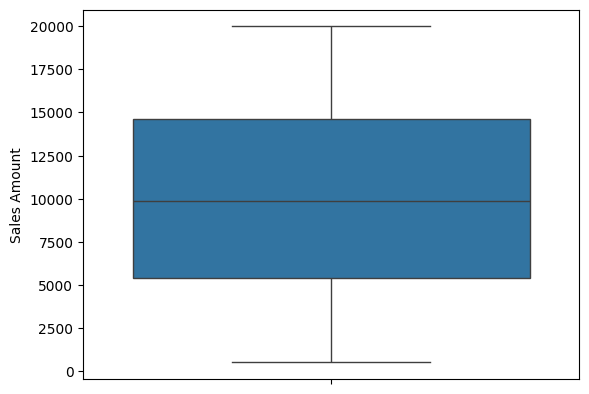

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Sales Amount'])
plt.show()

In [21]:
Q1 = df['Sales Amount'].quantile(0.25)
Q3 = df['Sales Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Sales Amount'] >= lower) & (df['Sales Amount'] <= upper)]

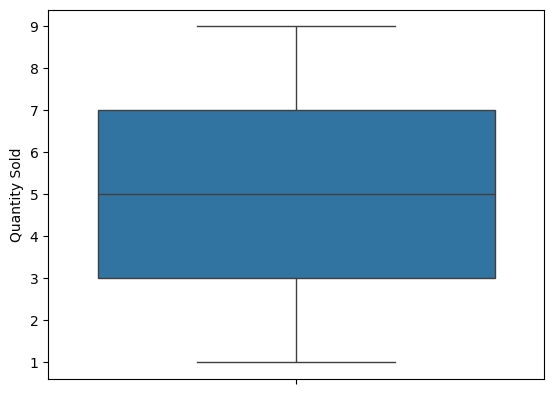

In [22]:
sns.boxplot(df['Quantity Sold'])
plt.show()

In [23]:
df.dtypes

,0
Order ID,object
Product Category,object
Sales Amount,float64
Quantity Sold,float64
Order Date,datetime64[ns]
Region,object
Customer Rating,float64
Payment Method,object
Discount (%),float64


In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [25]:
df = pd.get_dummies(df, columns=['Product Category', 'Region', 'Payment Method'])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Sales Amount', 'Quantity Sold', 'Customer Rating', 'Discount (%)']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [27]:
df.drop('Order ID', axis=1, inplace=True)

In [28]:
df.to_csv('cleaned_flipkart_sales_data.csv', index=False)

In [29]:
files.download('cleaned_flipkart_sales_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>